In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

## Load full test trajectory and fit the symbolic Markov chain

/Users/william/program_repos/lcs/icicl/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/william/program_repos/lcs/icicl/.venv/lib/python3.13/site-packages/matplotlib/axes/_axes.py:4733: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


Text(0, 0.5, 'Imaginary')

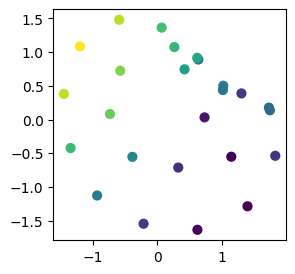

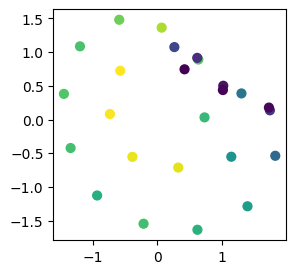

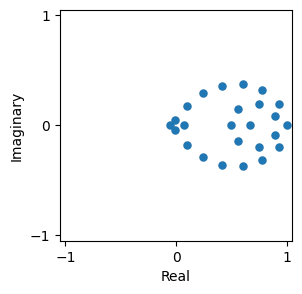

In [2]:
from icicl.operators import SymbolicMarkovChain, invariant_distribution

## Load test data
traj_test_out = np.load("./data/traj_test_out.pkl", allow_pickle=True)
x_test_out = traj_test_out[:, 0]

## Fit the symbolic Markov chain
mk = SymbolicMarkovChain()
label_order = mk.fit_predict(traj_test_out, 25, 1)
P_symbolic = mk.P_.copy()

## Compute the eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(P_symbolic)
sort_order = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_order]
eigvecs = eigvecs[:, sort_order]
centroids = mk.clusterer.cluster_centers_
pi_dist = invariant_distribution(P_symbolic)


plt.figure(figsize=(3, 3))
plt.scatter(centroids[:, 0], centroids[:, 1], c=eigvecs[:, 1], s=40)


plt.figure(figsize=(3, 3))
plt.scatter(centroids[:, 0], centroids[:, 1], c=pi_dist, s=40)


plt.figure(figsize=(3, 3))
plt.plot(np.real(eigvals), np.imag(eigvals), '.', markersize=10, color=np.ones(3) * 0.8)
plt.plot(np.real(eigvals)[:25], np.imag(eigvals)[:25], '.', markersize=10)
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.xlabel("Real")
plt.ylabel("Imaginary")

#### Tokenize the test time series, and map the full-state Markov chain symbols to the nearest $k$-gram in the tokenized univariate data

In [3]:
import torch
from scipy.spatial.distance import cdist

from icicl.models import ChronosTokenizer

VOCAB_SIZE = 100
CONTEXT_LENGTH = 32*4

tokenizer = ChronosTokenizer(VOCAB_SIZE, -3, 3)
tok_test_out, aux = tokenizer.encode_series(x_test_out, 100, 10)
test_tensor = torch.tensor(
        np.lib.stride_tricks.sliding_window_view(tok_test_out[:-1], CONTEXT_LENGTH),
        dtype=torch.long,
)

centroids_x = centroids[:, 0]

order = 8
centroid_closest_inds = order + np.argmin(cdist(centroids_x[:, None], x_test_out[order:][:, None]), axis=1)
offsets = np.arange(order - 1, -1, -1)   # shape (order,)
centroid_kgrams = tok_test_out[centroid_closest_inds[:, None] - offsets]


#### Load a trained transformer and run MCMC sampling to compute the transition matrix between successive $k$-grams

Running 0
Running 10
Running 20
Running 30
Running 40
Running 50
Running 60
Running 70
Running 80
Running 90


Text(0, 0.5, 'Current $k$-gram')

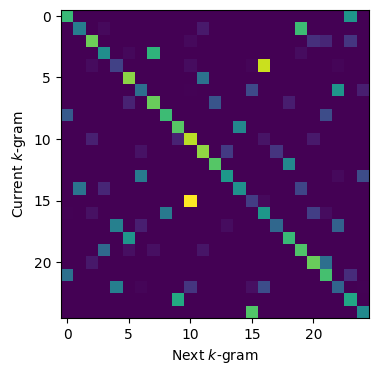

In [4]:
from icicl.transitions import transition_probs_mc
from icicl.models import load_model

## Load a trained transformer
model = load_model(f"data/tiny_lm.pt", device="cpu")

## Run MCMC sampling to compute the transition matrix between successive $k$-grams
K = len(centroid_kgrams)
P_reduced_sum = torch.zeros((K, K))
for ind in range(100):
    if ind % 10 == 0:
        print(f"Running {ind}", flush=True)
    P_reduced = transition_probs_mc(
        test_tensor, 
        torch.tensor(centroid_kgrams), 
        model,
        shift=1,
        n_input_samples=2000, 
        n_samples_per_input=1,
        temperature=0.00001,
        use_compile=True,
        normalize=False
    )
    P_reduced_sum += P_reduced

P_reduced = P_reduced_sum.clone()

## Normalize the transition matrix
row_sum = P_reduced.sum(dim=-1, keepdim=True)
row_sum  = row_sum.clamp_min(1e-30)
P_reduced = P_reduced / row_sum

plt.figure(figsize=(4, 4))
plt.imshow(P_reduced)
plt.xlabel("Next $k$-gram")
plt.ylabel("Current $k$-gram")


### Compare the spectrum of the full-state and implied transfer operators

Text(0, 0.5, 'Imaginary')

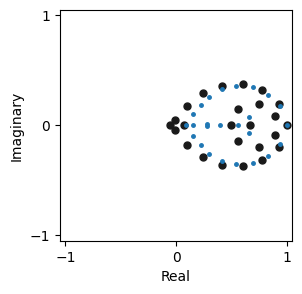

In [ ]:
eigvals, eigvecs = np.linalg.eig(P_reduced.T)
sort_order = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_order]
eigvecs = eigvecs[:, sort_order.copy()]

eigvals2, eigvecs2 = np.linalg.eig(P_symbolic.T)
sort_order = np.argsort(np.abs(eigvals2))[::-1]
eigvals2 = eigvals2[sort_order]
eigvecs2 = eigvecs2[:, sort_order.copy()]

plt.figure(figsize=(3, 3))
plt.plot(np.real(eigvals2), np.imag(eigvals2), '.', markersize=10, color=np.ones(3) * 0.1)
plt.plot(np.real(eigvals), np.imag(eigvals), '.', markersize=5)
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.xlabel("Real")
plt.ylabel("Imaginary")

